# Caricature Generation Pipeline
## Landmark-based Global & Local TPS Warping (Unpaired Dataset)

### Overview
This notebook implements the geometric warping stage of a caricature generation system.
The focus is on **landmark-based exaggeration** using:
- Global TPS warping for overall facial exaggeration
- Local TPS / Gaussian-RBF warping for feature-specific exaggeration
- Laplacian Pyramid Blending to reduce boundary artifacts

### Dataset Assumptions
- Images are organized by identity.
- Photographs (`Pxxxxx`) and caricatures (`Cxxxxx`) are **unpaired**.
- No pixel-level supervision is used.
- Exaggeration is modeled at the **geometry level**.

### Current Scope
- Only warping is implemented in this notebook.
- Style transfer (GAN-based) will be added later.
- A subset of images is used to validate the pipeline.

### Design Goals
- Modular outputs suitable for later GAN training
- User-controllable local exaggeration (eyes, lips, etc.)
- Replace uniform exaggeration constants with:
  - Procrustes-based global scaling
  - Gaussian-RBF local scaling
# Caricature Generation Pipeline
## Landmark-based Global & Local TPS Warping (Unpaired Dataset)

### Overview
This notebook implements the geometric warping stage of a caricature generation system.
The focus is on **landmark-based exaggeration** using:
- Global TPS warping for overall facial exaggeration
- Local TPS / Gaussian-RBF warping for feature-specific exaggeration
- Laplacian Pyramid Blending to reduce boundary artifacts

### Dataset Assumptions
- Images are organized by identity.
- Photographs (`Pxxxxx`) and caricatures (`Cxxxxx`) are **unpaired**.
- No pixel-level supervision is used.
- Exaggeration is modeled at the **geometry level**.

### Current Scope
- Only warping is implemented in this notebook.
- Style transfer (GAN-based) will be added later.
- A subset of images is used to validate the pipeline.

### Design Goals
- Modular outputs suitable for later GAN training
- User-controllable local exaggeration (eyes, lips, etc.)
- Replace uniform exaggeration constants with:
  - Procrustes-based global scaling
  - Gaussian-RBF local scaling

In [1]:
# ================================
# Core Python & Scientific Stack
# ================================
import os
import glob
import random
import numpy as np
import cv2

from tqdm import tqdm
import matplotlib.pyplot as plt

# ================================
# Landmark Detection
# ================================
import face_alignment
from skimage.transform import resize

# ================================
# Geometry & Warping Utilities
# ================================
from scipy.spatial import procrustes
from scipy.interpolate import Rbf

# ================================
# Reproducibility
# ================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ================================
# Dataset & Runtime Configuration
# ================================

# Root dataset path (adjust if needed)
DATA_ROOT = r"../data/raw/OriginalImages"

# Output directory for warped images
OUTPUT_ROOT = r"../data/processed/warped"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# Limit number of images for pipeline validation
limit = 100   # <<< IMPORTANT: pipeline-only run

# Image constraints (for GAN compatibility later)
TARGET_SIZE = 256   # standard GAN-friendly resolution

# ================================
# User-Controlled Exaggeration Flags
# ================================

# Global exaggeration (entire face)
ENABLE_GLOBAL_EXAGGERATION = True

# Local exaggeration switches
ENABLE_LOCAL_EYES = True
ENABLE_LOCAL_LIPS = True
ENABLE_LOCAL_NOSE = False
ENABLE_LOCAL_JAW = False

# Local exaggeration strength multipliers (relative)
LOCAL_RBF_STRENGTH = {
    "eyes": 1.0,
    "lips": 0.8,
    "nose": 0.5,
    "jaw": 0.6
}

# Gaussian RBF parameters (local influence)
RBF_SIGMA = {
    "eyes": 20.0,
    "lips": 18.0,
    "nose": 25.0,
    "jaw": 30.0
}

print("Environment setup complete.")
print(f"Processing limit set to {limit} images.")

Environment setup complete.
Processing limit set to 100 images.


In [2]:
# ================================
# FaceAlignment Initialization
# ================================

# Using 2D landmarks (sufficient for TPS & RBF warping)
fa = face_alignment.FaceAlignment(
    face_alignment.LandmarksType.TWO_D,
    device='cuda' if cv2.cuda.getCudaEnabledDeviceCount() > 0 else 'cpu',
    flip_input=False
)

print("FaceAlignment model loaded successfully.")

# ================================
# Landmark Index Definitions (68-point model)
# ================================
# Reference: dlib 68 landmark convention

LANDMARK_GROUPS = {
    "jaw": list(range(0, 17)),
    "right_eyebrow": list(range(17, 22)),
    "left_eyebrow": list(range(22, 27)),
    "nose": list(range(27, 36)),
    "right_eye": list(range(36, 42)),
    "left_eye": list(range(42, 48)),
    "lips_outer": list(range(48, 60)),
    "lips_inner": list(range(60, 68))
}

# Combined semantic regions (used for local exaggeration)
SEMANTIC_REGIONS = {
    "eyes": LANDMARK_GROUPS["left_eye"] + LANDMARK_GROUPS["right_eye"],
    "lips": LANDMARK_GROUPS["lips_outer"] + LANDMARK_GROUPS["lips_inner"],
    "nose": LANDMARK_GROUPS["nose"],
    "jaw": LANDMARK_GROUPS["jaw"]
}

print("Landmark groups defined:")
for k, v in SEMANTIC_REGIONS.items():
    print(f" - {k}: {len(v)} landmarks")

FaceAlignment model loaded successfully.
Landmark groups defined:
 - eyes: 12 landmarks
 - lips: 20 landmarks
 - nose: 9 landmarks
 - jaw: 17 landmarks


In [3]:
# ================================
# Discover Photo Images (Unpaired)
# ================================

photo_image_paths = []

for identity_name in sorted(os.listdir(DATA_ROOT)):
    identity_path = os.path.join(DATA_ROOT, identity_name)
    
    if not os.path.isdir(identity_path):
        continue
    
    # Collect only photo images (Pxxxxx)
    for img_name in os.listdir(identity_path):
        if img_name.lower().startswith("p") and img_name.lower().endswith((".jpg", ".png", ".jpeg")):
            full_path = os.path.join(identity_path, img_name)
            photo_image_paths.append(full_path)

# Shuffle to avoid identity bias
random.shuffle(photo_image_paths)

# Apply limit
photo_image_paths = photo_image_paths[:limit]

print(f"Total photo images selected: {len(photo_image_paths)}")
print("Sample paths:")
for p in photo_image_paths[:5]:
    print(" ", p)

Total photo images selected: 100
Sample paths:
  ../data/raw/OriginalImages\Jennifer Lawrence\P00018.jpg
  ../data/raw/OriginalImages\Keith Richards\P00011.jpg
  ../data/raw/OriginalImages\Ban Ki moon\P00006.jpg
  ../data/raw/OriginalImages\Hugh Grant\P00042.jpg
  ../data/raw/OriginalImages\Michael Schumacher\P00022.jpg


In [4]:
# ================================
# Landmark Extraction Pipeline
# ================================

processed_samples = []

def load_and_preprocess_image(img_path, target_size=TARGET_SIZE):
    """
    Load image, convert to RGB, resize to target_size x target_size.
    """
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (target_size, target_size))
    return img_rgb


print("Extracting landmarks from photo images...")

for img_path in tqdm(photo_image_paths):
    img = load_and_preprocess_image(img_path)
    if img is None:
        continue

    # FaceAlignment expects RGB images
    landmarks = fa.get_landmarks(img)

    # Skip images where no face is detected
    if landmarks is None or len(landmarks) == 0:
        continue

    # Use the first detected face
    lm = landmarks[0]  # shape: (68, 2)

    processed_samples.append({
        "image_path": img_path,
        "image": img,
        "landmarks": lm.astype(np.float32)
    })

print(f"Successfully processed images with landmarks: {len(processed_samples)}")

Extracting landmarks from photo images...


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:02<00:00,  1.61it/s]

Successfully processed images with landmarks: 100


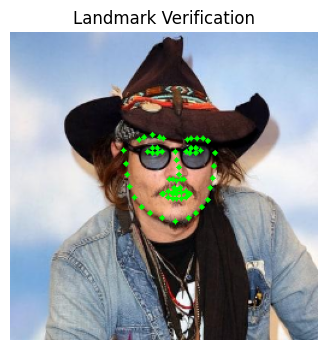

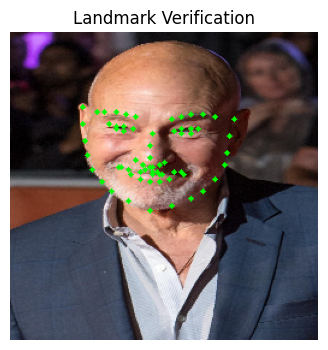

In [5]:
# Visualize one example with landmarks
sample = random.choice(processed_samples)
img_vis = sample["image"].copy()
lm_vis = sample["landmarks"]

for (x, y) in lm_vis.astype(int):
    cv2.circle(img_vis, (x, y), 2, (0, 255, 0), -1)

plt.figure(figsize=(4, 4))
plt.imshow(img_vis)
plt.axis("off")
plt.title("Landmark Verification")
plt.show()
# Visualize one example with landmarks
sample = random.choice(processed_samples)
img_vis = sample["image"].copy()
lm_vis = sample["landmarks"]

for (x, y) in lm_vis.astype(int):
    cv2.circle(img_vis, (x, y), 2, (0, 255, 0), -1)

plt.figure(figsize=(4, 4))
plt.imshow(img_vis)
plt.axis("off")
plt.title("Landmark Verification")
plt.show()

In [6]:
# ================================
# Face Mask Generation
# ================================

def generate_face_mask(image, landmarks):
    """
    Generate a binary face mask using the convex hull of landmarks.
    
    Args:
        image (np.ndarray): RGB image (H, W, 3)
        landmarks (np.ndarray): (68, 2) landmark coordinates
    
    Returns:
        mask (np.ndarray): Binary mask (H, W), values in {0,1}
    """
    h, w = image.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    # Compute convex hull over all landmarks
    hull = cv2.convexHull(landmarks.astype(np.int32))

    # Fill the convex hull
    cv2.fillConvexPoly(mask, hull, 1)

    return mask


# ================================
# Generate Masks for All Samples
# ================================

for sample in tqdm(processed_samples, desc="Generating face masks"):
    img = sample["image"]
    lm = sample["landmarks"]

    face_mask = generate_face_mask(img, lm)
    sample["mask"] = face_mask

print("Face masks generated successfully.")

Generating face masks: 100%|██████████████████████████████████████████████████████| 100/100 [00:00<00:00, 25015.23it/s]

Face masks generated successfully.


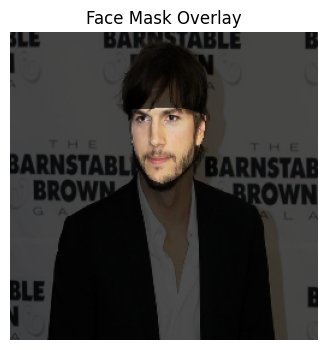

In [7]:
# Visualize mask overlay for sanity check
sample = random.choice(processed_samples)
img = sample["image"]
mask = sample["mask"]

overlay = img.copy()
overlay[mask == 0] = overlay[mask == 0] * 0.3

plt.figure(figsize=(4, 4))
plt.imshow(overlay.astype(np.uint8))
plt.axis("off")
plt.title("Face Mask Overlay")
plt.show()

In [8]:
# ================================
# Procrustes-Based Global Shape Modeling
# ================================

def normalize_landmarks(lm):
    """
    Center and scale landmarks for Procrustes analysis.
    """
    lm_centered = lm - lm.mean(axis=0, keepdims=True)
    scale = np.linalg.norm(lm_centered)
    lm_normalized = lm_centered / (scale + 1e-8)
    return lm_normalized


# Collect all landmark sets
all_landmarks = np.array([s["landmarks"] for s in processed_samples])

# Normalize landmarks
normalized_landmarks = np.array([normalize_landmarks(lm) for lm in all_landmarks])

# Compute global mean face (Procrustes mean approximation)
mean_shape = normalized_landmarks.mean(axis=0)

# Compute per-image global deviation vectors
for idx, sample in enumerate(processed_samples):
    lm_norm = normalized_landmarks[idx]
    
    # Global exaggeration vector (direction of deviation)
    global_exaggeration_vector = lm_norm - mean_shape
    
    sample["global_exaggeration"] = global_exaggeration_vector

print("Global Procrustes-based exaggeration vectors computed.")

Global Procrustes-based exaggeration vectors computed.


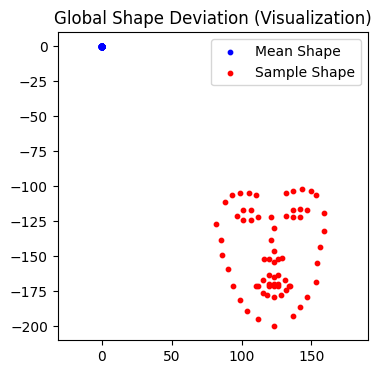

In [9]:
# Visualize mean face vs one sample
sample = random.choice(processed_samples)

plt.figure(figsize=(4, 4))
plt.scatter(mean_shape[:, 0], -mean_shape[:, 1], c='blue', label='Mean Shape', s=10)
plt.scatter(sample["landmarks"][:, 0], -sample["landmarks"][:, 1], 
            c='red', label='Sample Shape', s=10)
plt.legend()
plt.title("Global Shape Deviation (Visualization)")
plt.axis("equal")
plt.show()

In [10]:
# ================================
# Gaussian RBF-Based Local Exaggeration
# ================================

def compute_local_rbf_exaggeration(landmarks, semantic_regions, rbf_sigma, rbf_strength):
    """
    Compute local exaggeration vectors using Gaussian RBF interpolation.

    Args:
        landmarks (np.ndarray): (68, 2) landmark coordinates (normalized space)
        semantic_regions (dict): region_name -> landmark indices
        rbf_sigma (dict): Gaussian sigma per region
        rbf_strength (dict): exaggeration strength per region

    Returns:
        local_exaggeration (np.ndarray): (68, 2) local exaggeration vectors
    """
    local_exaggeration = np.zeros_like(landmarks)

    for region_name, indices in semantic_regions.items():
        # Check if user enabled this region
        enable_flag = globals().get(f"ENABLE_LOCAL_{region_name.upper()}", False)
        if not enable_flag:
            continue

        region_lm = landmarks[indices]

        # Region center
        center = region_lm.mean(axis=0)

        # Distance-based Gaussian weights
        distances = np.linalg.norm(landmarks - center, axis=1)
        weights = np.exp(-(distances ** 2) / (2 * (rbf_sigma[region_name] ** 2)))

        # Direction: move landmarks away from region center
        direction = landmarks - center

        # Normalize direction vectors
        norm = np.linalg.norm(direction, axis=1, keepdims=True) + 1e-8
        direction = direction / norm

        # Apply Gaussian RBF scaling
        strength = rbf_strength[region_name]
        local_exaggeration += (weights[:, None] * direction) * strength

    return local_exaggeration


# ================================
# Apply Local RBF Exaggeration
# ================================

for sample in processed_samples:
    lm = normalize_landmarks(sample["landmarks"])

    local_exag = compute_local_rbf_exaggeration(
        landmarks=lm,
        semantic_regions=SEMANTIC_REGIONS,
        rbf_sigma=RBF_SIGMA,
        rbf_strength=LOCAL_RBF_STRENGTH
    )

    sample["local_exaggeration"] = local_exag

print("Local Gaussian RBF exaggeration vectors computed.")
# ================================
# Gaussian RBF-Based Local Exaggeration
# ================================

def compute_local_rbf_exaggeration(landmarks, semantic_regions, rbf_sigma, rbf_strength):
    """
    Compute local exaggeration vectors using Gaussian RBF interpolation.

    Args:
        landmarks (np.ndarray): (68, 2) landmark coordinates (normalized space)
        semantic_regions (dict): region_name -> landmark indices
        rbf_sigma (dict): Gaussian sigma per region
        rbf_strength (dict): exaggeration strength per region

    Returns:
        local_exaggeration (np.ndarray): (68, 2) local exaggeration vectors
    """
    local_exaggeration = np.zeros_like(landmarks)

    for region_name, indices in semantic_regions.items():
        # Check if user enabled this region
        enable_flag = globals().get(f"ENABLE_LOCAL_{region_name.upper()}", False)
        if not enable_flag:
            continue

        region_lm = landmarks[indices]

        # Region center
        center = region_lm.mean(axis=0)

        # Distance-based Gaussian weights
        distances = np.linalg.norm(landmarks - center, axis=1)
        weights = np.exp(-(distances ** 2) / (2 * (rbf_sigma[region_name] ** 2)))

        # Direction: move landmarks away from region center
        direction = landmarks - center

        # Normalize direction vectors
        norm = np.linalg.norm(direction, axis=1, keepdims=True) + 1e-8
        direction = direction / norm

        # Apply Gaussian RBF scaling
        strength = rbf_strength[region_name]
        local_exaggeration += (weights[:, None] * direction) * strength

    return local_exaggeration


# ================================
# Apply Local RBF Exaggeration
# ================================

for sample in processed_samples:
    lm = normalize_landmarks(sample["landmarks"])

    local_exag = compute_local_rbf_exaggeration(
        landmarks=lm,
        semantic_regions=SEMANTIC_REGIONS,
        rbf_sigma=RBF_SIGMA,
        rbf_strength=LOCAL_RBF_STRENGTH
    )

    sample["local_exaggeration"] = local_exag

print("Local Gaussian RBF exaggeration vectors computed.")

Local Gaussian RBF exaggeration vectors computed.
Local Gaussian RBF exaggeration vectors computed.


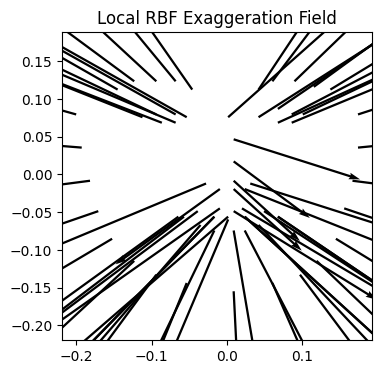

In [11]:
# Visualize local exaggeration vectors
sample = random.choice(processed_samples)
lm = normalize_landmarks(sample["landmarks"])
ex = sample["local_exaggeration"]

plt.figure(figsize=(4, 4))
plt.quiver(lm[:, 0], -lm[:, 1], ex[:, 0], -ex[:, 1], scale=1)
plt.title("Local RBF Exaggeration Field")
plt.axis("equal")
plt.show()

In [45]:
# ================================
# Combine Global and Local Exaggeration (FIXED)
# ================================
GLOBAL_SCALE_ALPHA = 1.0  # 1.0 = natural exaggeration, >1 stronger

def compute_target_landmarks(sample, alpha=0.15):  # Much smaller alpha!
    """
    Compute target landmarks using mean-face deviation (caricature principle).
    """
    lm = sample["landmarks"]
    
    # Global exaggeration: deviation from mean face (both in image space)
    global_exag = alpha * (lm - mean_face) if ENABLE_GLOBAL_EXAGGERATION else np.zeros_like(lm)
    
    # Local exaggeration needs to be MUCH more conservative
    # The local_exaggeration was computed in normalized space
    lm_normalized = normalize_landmarks(lm)
    
    # Get the scale factor used during normalization
    lm_centered = lm - lm.mean(axis=0, keepdims=True)
    scale = np.linalg.norm(lm_centered)
    
    # Scale the local exaggeration back to image space with VERY small multiplier
    local_exag = sample["local_exaggeration"] * scale * 0.01  # Much smaller: 0.01 instead of 0.3
    
    target_landmarks = lm + global_exag + local_exag
    
    # Safety clamp: ensure landmarks stay within reasonable bounds
    h, w = sample["image"].shape[:2]
    target_landmarks[:, 0] = np.clip(target_landmarks[:, 0], -w*0.1, w*1.1)
    target_landmarks[:, 1] = np.clip(target_landmarks[:, 1], -h*0.1, h*1.1)
    
    return target_landmarks.astype(np.float32)

# ================================
# Recompute Target Landmarks with Fixed Function
# ================================
for sample in processed_samples:
    sample["target_landmarks"] = compute_target_landmarks(sample)

print("Target landmarks recomputed with corrected scaling.")

# ================================
# Verify the fix
# ================================
sample = processed_samples[0]
src_lm = sample["landmarks"]
tgt_lm = sample["target_landmarks"]

print("\nAfter fix:")
print("Source landmarks (first 5):")
print(src_lm[:5])
print("\nTarget landmarks (first 5):")
print(tgt_lm[:5])
print("\nDifference (target - source, first 5):")
print((tgt_lm - src_lm)[:5])
print("\nMax displacement:", np.max(np.linalg.norm(tgt_lm - src_lm, axis=1)))
print("Mean displacement:", np.mean(np.linalg.norm(tgt_lm - src_lm, axis=1)))

Target landmarks recomputed with corrected scaling.

After fix:
Source landmarks (first 5):
[[ 82.  71.]
 [ 82.  81.]
 [ 84.  89.]
 [ 88.  96.]
 [ 91. 104.]]

Target landmarks (first 5):
[[ 78.55533   67.310745]
 [ 78.351654  77.84243 ]
 [ 80.38873   86.080605]
 [ 84.83451   93.29722 ]
 [ 87.96402  101.63131 ]]

Difference (target - source, first 5):
[[-3.4446716 -3.6892548]
 [-3.648346  -3.15757  ]
 [-3.611267  -2.9193954]
 [-3.1654892 -2.7027817]
 [-3.0359802 -2.3686905]]

Max displacement: 7.5721726
Mean displacement: 4.931428


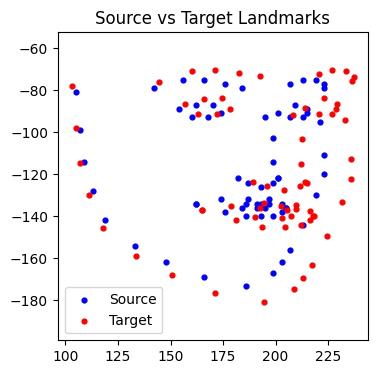

In [46]:
# Visualize source vs target landmarks
sample = random.choice(processed_samples)

plt.figure(figsize=(4, 4))
plt.scatter(sample["landmarks"][:, 0], -sample["landmarks"][:, 1],
            c='blue', label='Source', s=12)
plt.scatter(sample["target_landmarks"][:, 0], -sample["target_landmarks"][:, 1],
            c='red', label='Target', s=12)
plt.legend()
plt.title("Source vs Target Landmarks")
plt.axis("equal")
plt.show()

In [54]:
# ================================
# TPS Warping using Scipy RBF with Regularization
# ================================
from scipy.interpolate import Rbf

def tps_warp_rbf(image, src_pts, dst_pts, mask):
    """
    Apply TPS-like warp using Scipy's RBF interpolation with regularization.
    """
    h, w = image.shape[:2]
    
    # Create RBF interpolators for x and y displacements
    dx = dst_pts[:, 0] - src_pts[:, 0]
    dy = dst_pts[:, 1] - src_pts[:, 1]
    
    # Add small smoothing parameter to avoid singular matrix
    # Higher smooth = more regularization (0.1 to 1.0 is reasonable)
    smooth_param = 0.5
    
    try:
        # Create RBF interpolators (thin_plate is TPS kernel)
        rbf_x = Rbf(src_pts[:, 0], src_pts[:, 1], dx, 
                    function='thin_plate', smooth=smooth_param)
        rbf_y = Rbf(src_pts[:, 0], src_pts[:, 1], dy, 
                    function='thin_plate', smooth=smooth_param)
        
        # Create grid
        y_grid, x_grid = np.mgrid[0:h, 0:w]
        
        # Compute displacements for all pixels
        dx_grid = rbf_x(x_grid, y_grid)
        dy_grid = rbf_y(x_grid, y_grid)
        
        # Compute target coordinates (forward mapping)
        map_x = (x_grid + dx_grid).astype(np.float32)
        map_y = (y_grid + dy_grid).astype(np.float32)
        
        # Warp using remap
        warped = cv2.remap(image, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        
    except np.linalg.LinAlgError:
        # If still singular, return original image
        print("Warning: Singular matrix encountered, skipping warp")
        warped = image.copy()
    
    # Create feathered mask for blending
    kernel_size = 21
    feathered_mask = cv2.GaussianBlur(mask.astype(np.float32), (kernel_size, kernel_size), 0)
    feathered_mask = feathered_mask[:, :, np.newaxis]
    
    # Blend
    output = (warped * feathered_mask + image * (1 - feathered_mask)).astype(np.uint8)
    
    return output

# ================================
# Apply TPS Warping using RBF
# ================================
TPS_LANDMARK_IDX = list(range(68))

for sample in tqdm(processed_samples, desc="Applying TPS warping (RBF)"):
    img = sample["image"]
    src_lm = sample["landmarks"][TPS_LANDMARK_IDX]
    tgt_lm = sample["target_landmarks"][TPS_LANDMARK_IDX]
    mask = sample["mask"]
    
    warped_img = tps_warp_rbf(img, src_lm, tgt_lm, mask)
    sample["warped_tps"] = warped_img

print("TPS warping completed using RBF interpolation.")# ================================
# TPS Warping using Scipy RBF with Regularization
# ================================
from scipy.interpolate import Rbf

def tps_warp_rbf(image, src_pts, dst_pts, mask):
    """
    Apply TPS-like warp using Scipy's RBF interpolation with regularization.
    """
    h, w = image.shape[:2]
    
    # Create RBF interpolators for x and y displacements
    dx = dst_pts[:, 0] - src_pts[:, 0]
    dy = dst_pts[:, 1] - src_pts[:, 1]
    
    # Add small smoothing parameter to avoid singular matrix
    # Higher smooth = more regularization (0.1 to 1.0 is reasonable)
    smooth_param = 0.5
    
    try:
        # Create RBF interpolators (thin_plate is TPS kernel)
        rbf_x = Rbf(src_pts[:, 0], src_pts[:, 1], dx, 
                    function='thin_plate', smooth=smooth_param)
        rbf_y = Rbf(src_pts[:, 0], src_pts[:, 1], dy, 
                    function='thin_plate', smooth=smooth_param)
        
        # Create grid
        y_grid, x_grid = np.mgrid[0:h, 0:w]
        
        # Compute displacements for all pixels
        dx_grid = rbf_x(x_grid, y_grid)
        dy_grid = rbf_y(x_grid, y_grid)
        
        # Compute target coordinates (forward mapping)
        map_x = (x_grid + dx_grid).astype(np.float32)
        map_y = (y_grid + dy_grid).astype(np.float32)
        
        # Warp using remap
        warped = cv2.remap(image, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        
    except np.linalg.LinAlgError:
        # If still singular, return original image
        print("Warning: Singular matrix encountered, skipping warp")
        warped = image.copy()
    
    # Create feathered mask for blending
    kernel_size = 21
    feathered_mask = cv2.GaussianBlur(mask.astype(np.float32), (kernel_size, kernel_size), 0)
    feathered_mask = feathered_mask[:, :, np.newaxis]
    
    # Blend
    output = (warped * feathered_mask + image * (1 - feathered_mask)).astype(np.uint8)
    
    return output

# ================================
# Apply TPS Warping using RBF
# ================================
TPS_LANDMARK_IDX = list(range(68))

for sample in tqdm(processed_samples, desc="Applying TPS warping (RBF)"):
    img = sample["image"]
    src_lm = sample["landmarks"][TPS_LANDMARK_IDX]
    tgt_lm = sample["target_landmarks"][TPS_LANDMARK_IDX]
    mask = sample["mask"]
    
    warped_img = tps_warp_rbf(img, src_lm, tgt_lm, mask)
    sample["warped_tps"] = warped_img

print("TPS warping completed using RBF interpolation.")

Applying TPS warping (RBF): 100%|████████████████████████████████████████████████████| 100/100 [00:29<00:00,  3.42it/s]


TPS warping completed using RBF interpolation.


Applying TPS warping (RBF): 100%|████████████████████████████████████████████████████| 100/100 [00:30<00:00,  3.30it/s]

TPS warping completed using RBF interpolation.


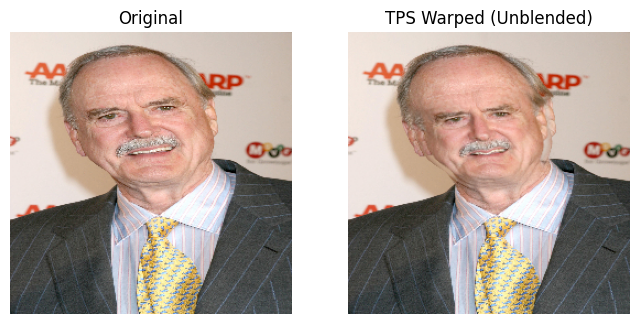

In [55]:
# Visualize TPS warped output
sample = random.choice(processed_samples)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample["image"])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample["warped_tps"])
plt.title("TPS Warped (Unblended)")
plt.axis("off")

plt.show()


In [29]:
# ================================
# Laplacian Pyramid Blending
# ================================

def gaussian_pyramid(img, levels):
    gp = [img.astype(np.float32)]
    for _ in range(levels):
        img = cv2.pyrDown(img)
        gp.append(img.astype(np.float32))
    return gp


def laplacian_pyramid(img, levels):
    gp = gaussian_pyramid(img, levels)
    lp = []
    for i in range(levels):
        size = (gp[i].shape[1], gp[i].shape[0])
        expanded = cv2.pyrUp(gp[i+1], dstsize=size)
        lap = gp[i] - expanded
        lp.append(lap)
    lp.append(gp[-1])
    return lp


def laplacian_blend(img1, img2, mask, levels=5):
    """
    img1: original image
    img2: warped image
    mask: binary face mask (0 or 1)
    """
    # Convert mask to 3-channel float
    mask = mask.astype(np.float32)
    mask = cv2.GaussianBlur(mask, (31, 31), 0)
    mask = np.clip(mask, 0, 1)
    mask_3 = np.repeat(mask[:, :, None], 3, axis=2)

    # Build pyramids
    lp1 = laplacian_pyramid(img1, levels)
    lp2 = laplacian_pyramid(img2, levels)
    gp_mask = gaussian_pyramid(mask_3, levels)

    # Blend pyramids
    blended_pyramid = []
    for l1, l2, gm in zip(lp1, lp2, gp_mask):
        blended = gm * l2 + (1 - gm) * l1
        blended_pyramid.append(blended)

    # Reconstruct image
    img_blend = blended_pyramid[-1]
    for i in range(levels - 1, -1, -1):
        size = (blended_pyramid[i].shape[1], blended_pyramid[i].shape[0])
        img_blend = cv2.pyrUp(img_blend, dstsize=size)
        img_blend = img_blend + blended_pyramid[i]

    return np.clip(img_blend, 0, 255).astype(np.uint8)

In [30]:
# ================================
# Apply Laplacian Blending
# ================================

BLEND_LEVELS = 5

for sample in tqdm(processed_samples, desc="Laplacian blending"):
    original = sample["image"]
    warped = sample["warped_tps"]
    mask = sample["mask"]

    blended = laplacian_blend(
        img1=original,
        img2=warped,
        mask=mask,
        levels=BLEND_LEVELS
    )

    sample["final_blended"] = blended

print("Laplacian pyramid blending completed.")

Laplacian blending: 100%|███████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 207.04it/s]

Laplacian pyramid blending completed.


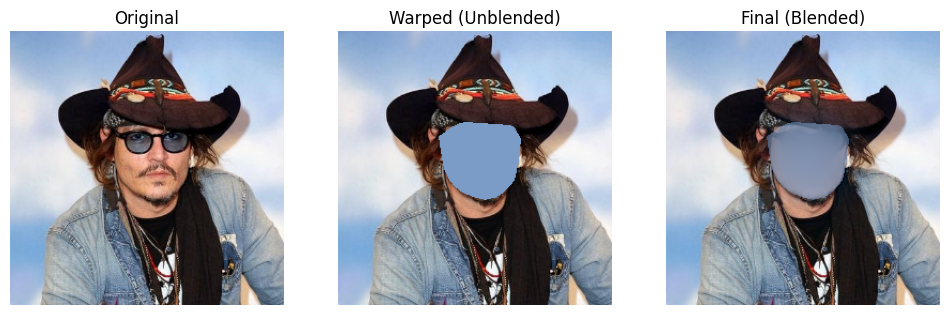

In [31]:
sample = random.choice(processed_samples)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample["image"])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample["warped_tps"])
plt.title("Warped (Unblended)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sample["final_blended"])
plt.title("Final (Blended)")
plt.axis("off")

plt.show()